## **Tugas 1: K-Means**

### **Langkah 1 — Load Data & Inspeksi**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('Mall_Customers.csv')
print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB
None
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


### **Langkah 2 — Tentukan Fitur yang Tepat**

In [2]:
# Ambil 2 fitur
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Standarisasi (opsional, tapi bagus untuk KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape X:", X_scaled.shape)

Shape X: (200, 2)


### **Langkah 3 — Cari k Terbaik dengan Metode Elbow**

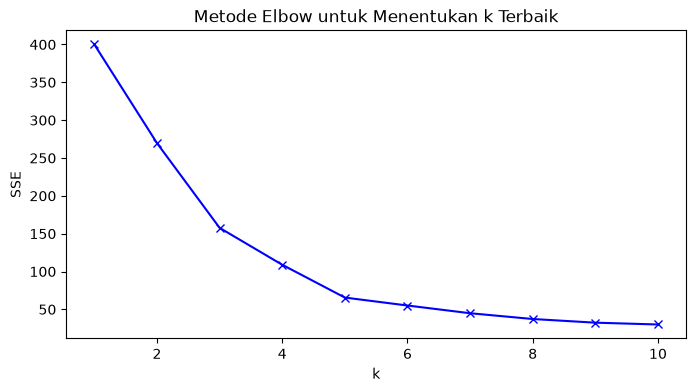

k=1; SSE=400.00
k=2; SSE=269.69
k=3; SSE=157.70
k=4; SSE=108.92
k=5; SSE=65.57
k=6; SSE=55.06
k=7; SSE=44.86
k=8; SSE=37.23
k=9; SSE=32.39
k=10; SSE=29.98


In [4]:
sse = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, sse, 'bx-')
plt.xlabel('k')
plt.ylabel('SSE')
plt.title('Metode Elbow untuk Menentukan k Terbaik')
plt.show()

# Print nilai SSE tiap k
for idx, val in enumerate(sse, start=1):
    print(f'k={idx}; SSE={val:.2f}')

### **Langkah 4 — Buat Model K-Means dengan k Terbaik**

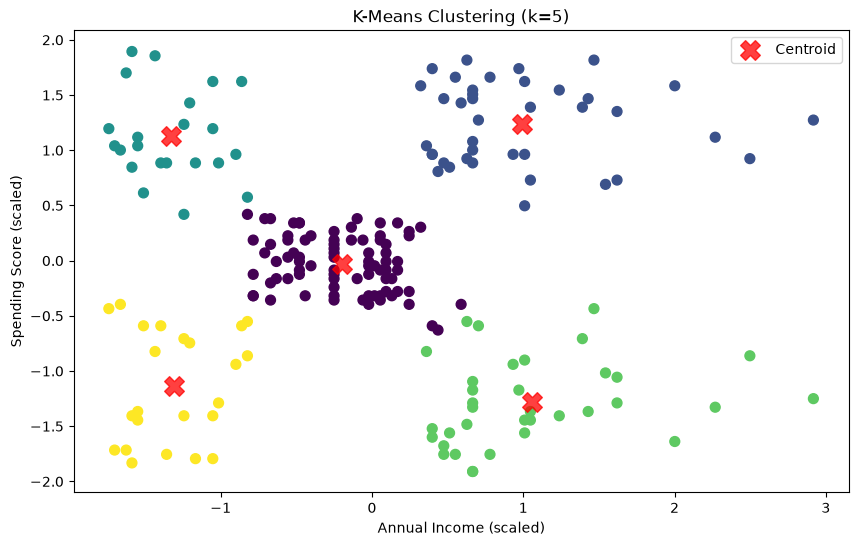

Nilai SSE akhir: 65.57


In [5]:
# Ganti 5 dengan k terbaik hasil elbow
k_optimal = 5
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)

# Visualisasi hasil clustering
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans, s=50, cmap='viridis')

# Plot centroid
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X', label='Centroid')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.title(f'K-Means Clustering (k={k_optimal})')
plt.legend()
plt.show()

# Print SSE akhir
print(f'Nilai SSE akhir: {kmeans.inertia_:.2f}')

## **Tugas 2: DBSCAN**

### **Langkah 1 — Buat Dataset make_moons**

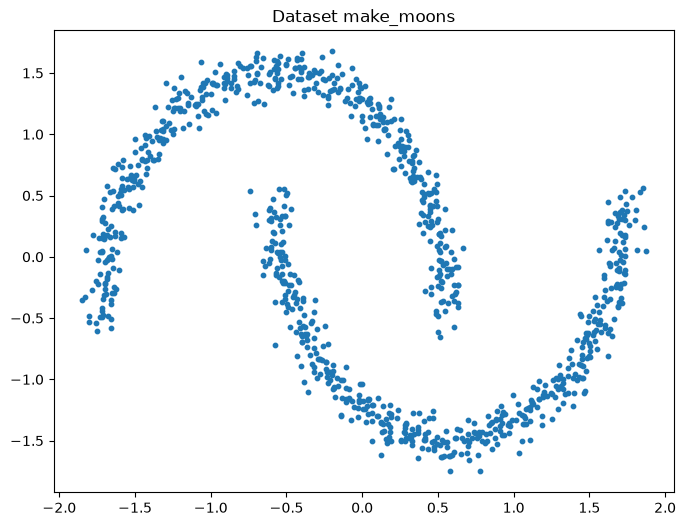

In [6]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

X_moons, y_moons = make_moons(n_samples=1000, noise=0.05, random_state=42)
X_moons = StandardScaler().fit_transform(X_moons)

# Visualisasi
plt.figure(figsize=(8, 6))
plt.scatter(X_moons[:, 0], X_moons[:, 1], s=10)
plt.title('Dataset make_moons')
plt.show()

### **Langkah 2 — DBSCAN dengan eps=0.2, min_samples=5**

In [7]:
from sklearn.cluster import DBSCAN
from sklearn import metrics

db = DBSCAN(eps=0.2, min_samples=5).fit(X_moons)
labels = db.labels_

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print(f"Estimated number of clusters: {n_clusters_}")
print(f"Estimated number of noise points: {n_noise_}")

Estimated number of clusters: 2
Estimated number of noise points: 0


### **Langkah 3 — Evaluasi Metrik**

In [8]:
print(f"Homogeneity: {metrics.homogeneity_score(y_moons, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(y_moons, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(y_moons, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(y_moons, labels):.3f}")
print("Adjusted Mutual Information:"
      f" {metrics.adjusted_mutual_info_score(y_moons, labels):.3f}")
print(f"Silhouette Coefficient: {metrics.silhouette_score(X_moons, labels):.3f}")

Homogeneity: 1.000
Completeness: 1.000
V-measure: 1.000
Adjusted Rand Index: 1.000
Adjusted Mutual Information: 1.000
Silhouette Coefficient: 0.391


### **Langkah 4 — Visualisasi DBSCAN**

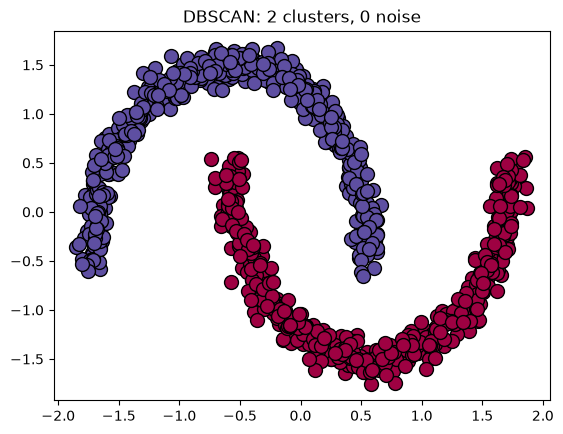

In [9]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X_moons[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], "o",
             markerfacecolor=tuple(col),
             markeredgecolor="k",
             markersize=10)

    xy = X_moons[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], "o",
             markerfacecolor=tuple(col),
             markeredgecolor="k",
             markersize=4)

plt.title(f"DBSCAN: {n_clusters_} clusters, {n_noise_} noise")
plt.show()

### **Langkah 5 — Eksperimen dengan Berbagai eps dan min_samples**

In [10]:
eps_values = [0.05, 0.1, 0.3, 0.5]
min_samples_values = [3, 10, 20]

hasil = []
for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms).fit(X_moons)
        labels = db.labels_
        n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise_ = list(labels).count(-1)
        sil = metrics.silhouette_score(X_moons, labels) if n_clusters_ > 1 else -1
        hasil.append({
            'eps': eps,
            'min_samples': ms,
            'n_clusters': n_clusters_,
            'n_noise': n_noise_,
            'silhouette': round(sil, 3)
        })

hasil_df = pd.DataFrame(hasil)
print(hasil_df)

     eps  min_samples  n_clusters  n_noise  silhouette
0   0.05            3          69      186       0.113
1   0.05           10           3      970      -0.294
2   0.05           20           0     1000      -1.000
3   0.10            3           2       14       0.252
4   0.10           10           7       57       0.162
5   0.10           20           6      850      -0.360
6   0.30            3           2        0       0.391
7   0.30           10           2        0       0.391
8   0.30           20           2        0       0.391
9   0.50            3           2        0       0.391
10  0.50           10           2        0       0.391
11  0.50           20           2        0       0.391
